# 97 - Code Challenge: A Smaller DCGAN

**Section:** GANs | **Prereqs:** `GANs/CNN_GANs_Guassians.ipynb` | **Next:** `GANs/CNN_GANs_FMNIST.ipynb`

The same Gaussian task with three layers per network instead of five, and larger
strides (3 and 4) to cover the same 64x64 in fewer steps.

**The question:** how much architecture does a GAN actually need? For data this
simple, less than the DCGAN default - and a smaller model trains faster and is
often *more* stable, because there is less capacity for either network to
overpower the other.

**The stride arithmetic changes with the layer count.** Fewer layers means each
must downsample or upsample more:
- generator: `stride=4` three times gives 1 -> 4 -> 16 -> 64,
- discriminator: `stride=3` with `kernel=4` shrinks 64 -> 21 -> 6 -> 1.

Note that `kernel=4, stride=3` does *not* divide evenly, which is the classic
setup for checkerboard artifacts in the generator. On blobs it is invisible; on
textured images it would not be.

**The general lesson:** match model capacity to task complexity. An oversized GAN
on simple data is more likely to collapse, not less.

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchsummary
import sys

In [254]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [255]:
# The same Gaussian blob data as the previous notebook, so the comparison is
# purely architectural.
nImages = 3000
imgSize = 64

x   = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)


# initialize tensors containing images and labels
images = torch.zeros(nImages,1,imgSize,imgSize)

for i in range(nImages):

  # create the gaussian with random centers
  ro = 2*np.random.randn(2) # ro = random offset
  width = np.random.rand()/.6 + 1.8 # random width
  G  = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / (2*width**2) )

  # and add noise
  G  = G + np.random.randn(imgSize,imgSize)/5

  # add to the tensor
  images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize).to(device)

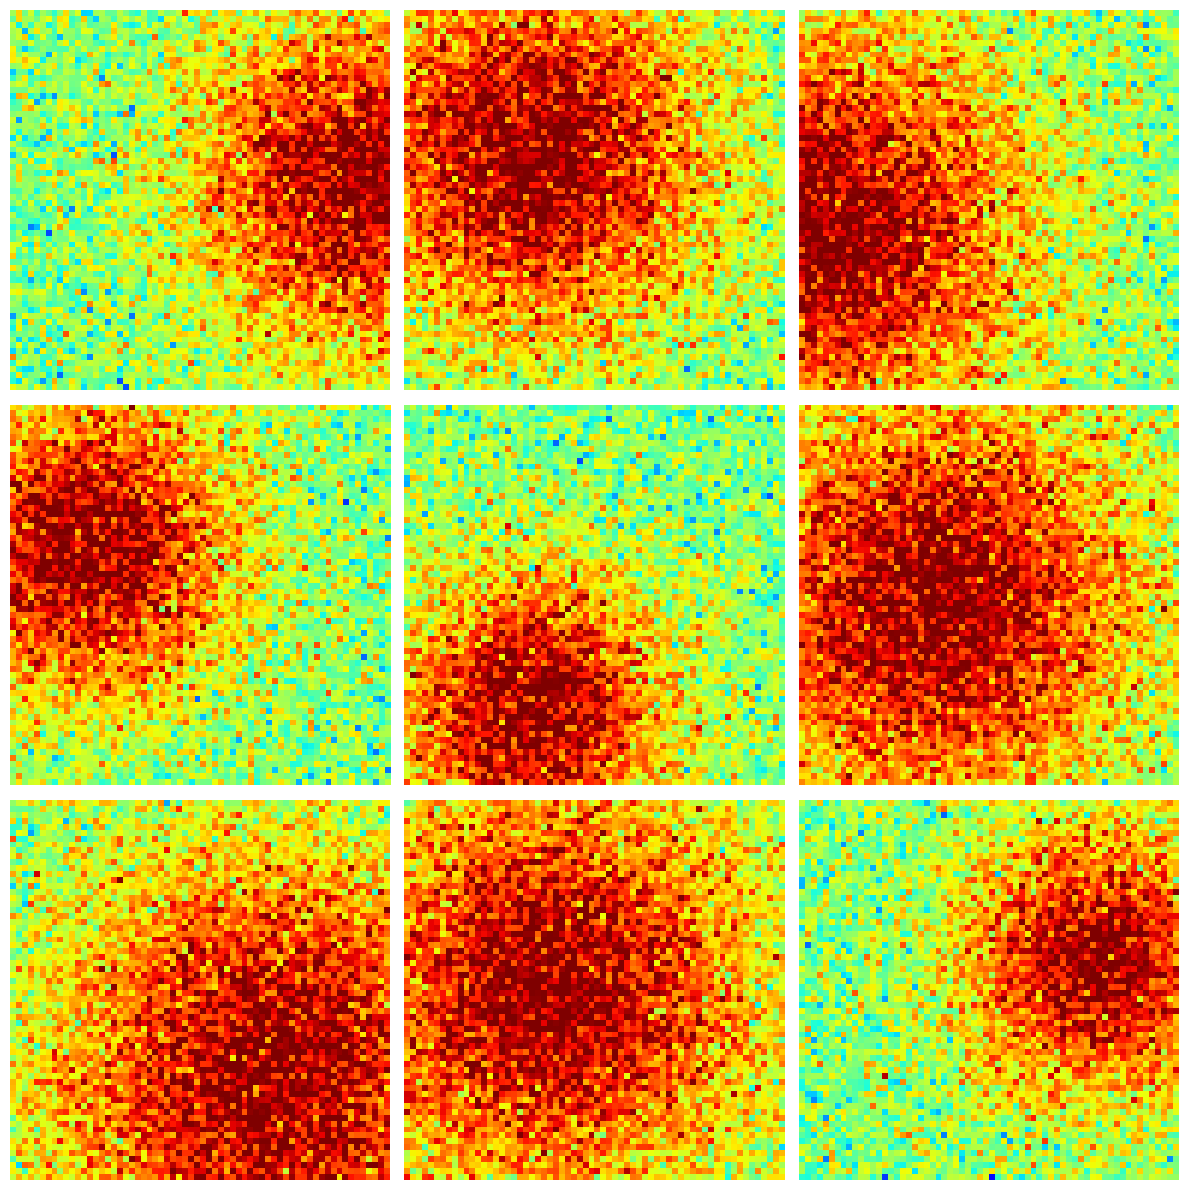

In [256]:
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(2*nImages, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1,cmap='jet')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [257]:
# The discriminator with THREE convolutions instead of five, stride 3 instead
# of 2: 64 -> 21 -> 6 -> 1.
# The commented-out conv4/conv5 are the layers that were removed - a useful
# record of what changed.
class discriminator(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,64,4,3,0,bias=False)
    self.conv2 = nn.Conv2d(64,128,4,3,0,bias=False)
    self.conv3 = nn.Conv2d(128,1,4,3,0,bias=False)
    # self.conv4 = nn.Conv2d(256,512,4,2,1,bias=False)
    # self.conv5 = nn.Conv2d(512,1,4,2,0,bias=False)

    self.bnorm2 = nn.BatchNorm2d(128)
    # self.bnorm3 = nn.BatchNorm2d(256)
    # self.bnorm4 = nn.BatchNorm2d(512)


  def forward(self,x):
    x = F.leaky_relu(self.conv1(x),negative_slope=0.2)
    x = self.bnorm2(F.leaky_relu(self.conv2(x),negative_slope=0.2))
    # x = self.bnorm3(F.leaky_relu(self.conv3(x),negative_slope=0.2))
    # x = self.bnorm4(F.leaky_relu(self.conv4(x),negative_slope=0.2))

    x  = torch.sigmoid( self.conv3(x) ).view(-1,1)

    return x

In [258]:
dnet = discriminator().to(device)
dnet

discriminator(
  (conv1): Conv2d(1, 64, kernel_size=(4, 4), stride=(3, 3), bias=False)
  (conv2): Conv2d(64, 128, kernel_size=(4, 4), stride=(3, 3), bias=False)
  (conv3): Conv2d(128, 1, kernel_size=(4, 4), stride=(3, 3), bias=False)
  (bnorm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [259]:
dnet(torch.randn((10,1,64,64)).to(device)).shape

torch.Size([10, 1])

In [260]:
# The generator, also three layers, stride 4: 1 -> 4 -> 16 -> 64.
# Note kernel=4 with stride=4 divides evenly (good), while the discriminator's
# kernel=4 with stride=3 does not - the uneven-overlap condition that produces
# checkerboard artifacts. Invisible on blobs, not on textured images.
class generatorNet(nn.Module):
  def __init__(self):
    super().__init__()

    # convolution layers
    self.conv1 = nn.ConvTranspose2d(100,256, 4, 4, 0, bias=False)
    self.conv2 = nn.ConvTranspose2d(256,128, 4, 4, 0, bias=False)
    self.conv3 = nn.ConvTranspose2d(128,1, 4, 4, 0, bias=False)
    # self.conv4 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
    # self.conv5 = nn.ConvTranspose2d(64,   1, 4, 2, 1, bias=False)

    # batchnorm
    self.bn1 = nn.BatchNorm2d(256)
    self.bn2 = nn.BatchNorm2d(128)
    # self.bn3 = nn.BatchNorm2d(128)
    # self.bn4 = nn.BatchNorm2d( 64)


  def forward(self,x):

    x = F.relu( self.bn1(self.conv1(x)) )
    x = F.relu( self.bn2(self.conv2(x)) )
    # x = F.relu( self.bn3(self.conv3(x)) )
    # x = F.relu( self.bn4(self.conv4(x)) )
    x = torch.tanh( self.conv3(x) )

    return x

torch.Size([10, 1, 64, 64])


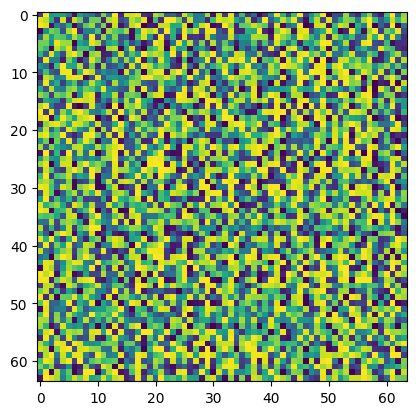

In [261]:
gnet = generatorNet().to(device)

y = gnet(torch.randn(10,100,1,1).to(device))
print(y.shape)
plt.imshow(y[0].squeeze().detach().cpu().numpy());

## Training the model

In [262]:
# lr=2e-4 with betas=(0.5,0.999) - the DCGAN defaults.
lossfunc = nn.BCELoss()

epochs = 10500
batchsize = 86

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=.0002, betas=(.5,.999))
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=.0002, betas=(.5,.999))

In [263]:
torch.randint(images.shape[0],(batchsize,)) # High = image.shape[0], and chosses random digits of the size (batchsize,)

tensor([ 921,  139, 2639, 1343, 1710, 2830, 1055, 1376, 2363, 2122, 2884, 1155,
        2649, 1494, 1771, 2979,  483,  439, 1627,  786, 1398, 1504,  853, 2431,
          30, 2927, 2341, 2587, 2339, 1747, 2270, 1590,  430, 2893,  744,  878,
         999, 2570,  927,  124, 1341, 1156, 1772,   88, 2358, 2364, 2526, 2828,
         256, 2544, 1273,  668, 2868,   97,  930, 2006, 1537, 2967, 1975, 1479,
        2945, 1302, 1290, 2063, 1528, 1194,  998,  436,  987,  356, 1112, 1251,
         196,  625, 1724, 2772,  655,   22,  454,  790, 1383, 2917, 2815, 2045,
        1489, 2776])

In [264]:
# THE GAN TRAINING LOOP. Two models, two optimizers, one alternating step:
#
# 1. DISCRIMINATOR: show it real images labelled 1 and fake images labelled 0,
#    and minimise BCE on both. It learns to tell them apart.
# 2. GENERATOR: make fresh fakes, run them through the discriminator, and
#    minimise BCE against label 1 - i.e. train the generator to make the
#    discriminator say 'real'.
#
# The label flip in step 2 is the whole trick: the generator has no direct
# target image, only the discriminator's opinion, so 'be more convincing' is
# expressed as 'make D output 1'.
#
# Fakes are REGENERATED between the two steps. Reusing the step-1 fakes would
# backpropagate through a stale graph, and torch would raise.
#
# What to watch: d_loss and g_loss should stay in tension. If d_loss collapses
# to 0 the discriminator won and the generator gets no useful gradient; if
# g_loss collapses the generator found a blind spot. Neither loss going to zero
# is success - equilibrium is.
losses = torch.zeros((epochs,2))
dnet_decisions = torch.zeros((epochs,2))

# How many times to train the generator per discriminator update
k_g = 1

for epoch in range(epochs):

  randidx = torch.randint(images.shape[0],(batchsize,))
  real_images = images[randidx,:].to(device)
  fake_images = gnet( torch.randn((batchsize,100,1,1)).to(device) )

  real_labels = torch.ones((batchsize,1),device=device)
  fake_labels = torch.zeros((batchsize,1), device=device)

  # Training the discriminator

  pred_real = dnet(real_images)
  d_loss_real = lossfunc(pred_real, real_labels)

  pred_fake = dnet(fake_images)
  d_loss_fake = lossfunc(pred_fake, fake_labels)

  d_loss = d_loss_real + d_loss_fake

  losses[epoch,0] = d_loss.item()
  dnet_decisions[epoch,0] = torch.mean((pred_real > 0.5).float()).detach()

  d_optimizer.zero_grad()
  d_loss.backward()
  d_optimizer.step()

  # Training the generator (k_g times)
  for _ in range(k_g):
    fake_images = gnet(torch.randn((batchsize,100,1,1)).to(device))
    fake_preds = dnet(fake_images)

    g_loss = lossfunc(fake_preds, real_labels) # We compare the predictions to the real images

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

  losses[epoch,1] = g_loss.item()
  dnet_decisions[epoch,1] = torch.mean((fake_preds > 0.5).float()).detach()


  if (epoch+1) % 100 == 0 or epoch == epochs -1:

    msg = f'Epoch {epoch+1}/{epochs}'
    sys.stdout.write('\r' + msg)
    sys.stdout.flush()


Epoch 10500/10500

In [265]:
def smooth(x,k=15):
  return np.convolve(x,np.ones(k)/k,mode='same')

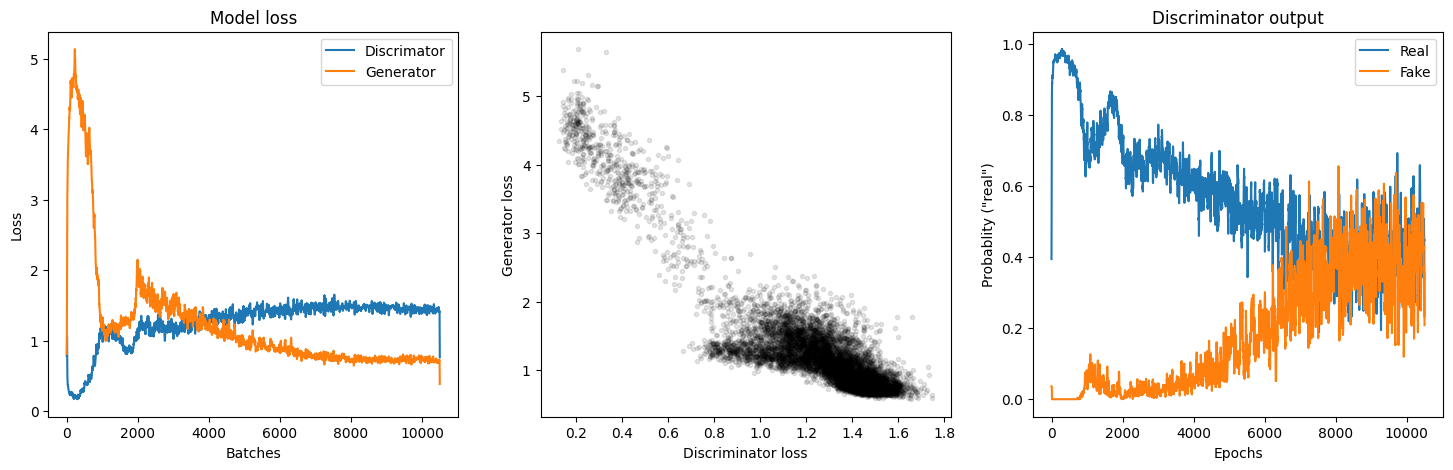

In [266]:
# The three GAN diagnostics:
# LEFT   - both losses over time. Look for sustained oscillation, not
#          convergence. A GAN that 'converges' has usually collapsed.
# MIDDLE - discriminator loss against generator loss. A diagonal cloud means the
#          two are trading blows; a point in one corner means one has won.
# RIGHT  - the discriminator's decisions on real and fake. At equilibrium both
#          approach 0.5: it can no longer tell them apart. That is the target,
#          and it is the closest thing a GAN has to an accuracy metric.
# Compare against the five-layer version: on data this simple the small model
# usually trains faster and at least as stably. Capacity should match task
# complexity - an oversized GAN is MORE prone to collapse, not less.
fig,ax = plt.subplots(1,3,figsize=(18,5))

ax[0].plot(smooth(losses[:,0]))
ax[0].plot(smooth(losses[:,1]))
ax[0].set_xlabel('Batches')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])
# ax[0].set_xlim([500,900])
# ax[0].set_ylim([0,2.5])

ax[1].plot(losses[200:,0],losses[200:,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(smooth(dnet_decisions[:,0]))
ax[2].plot(smooth(dnet_decisions[:,1]))
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()

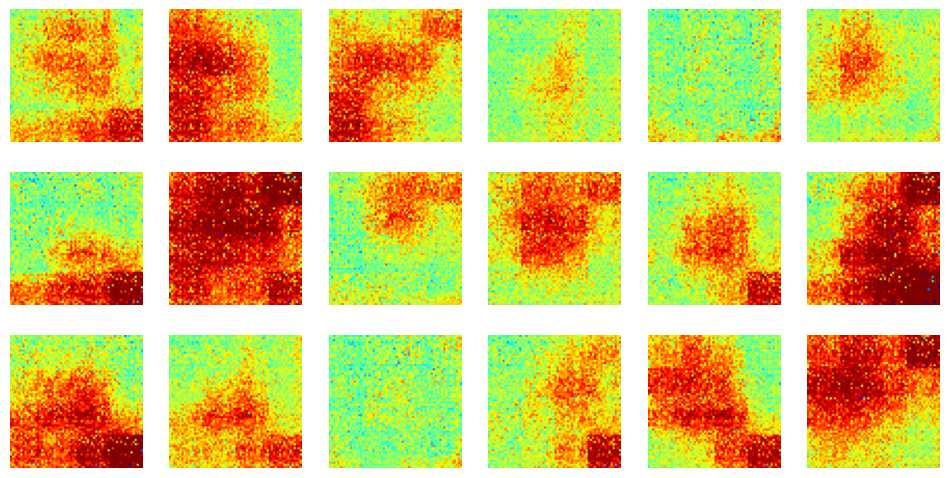

In [267]:
# Generated blobs from the smaller network.
gnet.eval()
fake_data = gnet( torch.randn(batchsize,100,1,1).to(device) ).cpu()

# and visualize...
fig,axs = plt.subplots(3,6,figsize=(12,6))
for i,ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i,].detach().squeeze(),cmap='jet',vmin=-1,vmax=1)
  ax.axis('off')

plt.show()

## CONCLUSION:

---
CNN GANs require a certain level of complexity for them to work.


